# Expectation Decider Project

## Project Introduction

The objective of this project is to analyze the factors that influence a student's success in a competitive mathematics examination using probability and statistical techniques. A dataset of 200 students is generated, containing information about study hours, attendance percentage, participation in group discussions, previous test scores, and final examination results.

This project applies various concepts of probability, including empirical and theoretical probability, random variables, probability distributions, contingency tables, conditional probability, independence of events, Venn diagrams, and Bayes' Theorem. The analysis aims to identify patterns in student performance and determine which factors have the greatest impact on the probability of passing the final examination.

The project demonstrates how probability and statistics can be used in educational research to make data-driven predictions and support decision-making.


In [9]:
import os
print("Current folder:", os.getcwd())
print("Files here:", os.listdir())

Current folder: C:\Users\PRERITA
Files here: ['.anaconda', '.conda', '.continuum', '.copilot', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.vscode', '.vscode-shared', 'anaconda3', 'ansel', 'AppData', 'Application Data', 'Cookies', 'Documents', 'Downloads', 'Favorites', 'firstprojecttt.ipynb', 'Links', 'Local Settings', 'Microsoft', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{d0eae55d-231e-11f1-94a8-14b5cdd0ee0a}.TM.blf', 'NTUSER.DAT{d0eae55d-231e-11f1-94a8-14b5cdd0ee0a}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{d0eae55d-231e-11f1-94a8-14b5cdd0ee0a}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'Untitled.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb', 'Untitled3.ipynb']


In [10]:
# --- Cell 1: Load libraries and dataset ---
import pandas as pd

df = pd.read_csv(r'C:\Users\PRERITA\Downloads\student_dataset.csv')
total_students = len(df)
df.head(10)

,student_id,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,1,12.0,79.3,No,84.4,Pass
1,2,9.4,81.7,Yes,77.9,Pass
2,3,12.6,88.0,Yes,87.8,Pass
3,4,16.1,87.6,No,91.8,Fail
4,5,9.1,58.5,No,69.3,Fail
5,6,9.1,63.7,No,64.9,Pass
6,7,16.3,81.2,No,95.5,Pass
7,8,13.1,81.2,No,100.0,Pass
8,9,8.1,81.2,No,79.7,Fail
9,10,12.2,100.0,No,87.9,Pass


                                    QUESTION 1: UNDERSTANDING BASICS OF PROBABILITY!!!
What is Probability?
==Probability tells us how likely an event is to happen.

The value of probability is always between 0 and 1.

Formula :- P(Event) = Number of favourable outcomes / Total number of outcomes

                                    ***Key Probability Terminology***
1.Experiment :- Selecting one student from the dataset.

2.Sample Space :- All 200 students.

3.Event :- Any specific result. Example : Student passes the exam.

4.Independent Events :- Two events that do not affect each other.

5.Conditional Probability :- Probability of one event given another event has already happened.

In [11]:
# ---  Example 1 - Probability of Passing ---
student_pass = len(df[df["final_exam_pass"] == "Pass"])
probability_pass = student_pass / total_students
print("Probability of Passing =", probability_pass)

# ---  Example 2 - Probability of Study Hours > 10 ---
student_more_than_ten = len(df[df["study_hours"] > 10])
probability_more_than_ten = student_more_than_ten / total_students
print("Probability of Study Hours > 10 =", probability_more_than_ten)

# --- Example 3 - Probability of Group Discussion = Yes ---
student_group_discussion_yes = len(df[df["group_discussion"] == "Yes"])
probability_group_discussion = student_group_discussion_yes / total_students
print("Probability of Group Discussion =", probability_group_discussion)

Probability of Passing = 0.51
Probability of Study Hours > 10 = 0.495
Probability of Group Discussion = 0.33


                                        ***Question 2: Types of Probability***
1. Empirical Probability
==Empirical probability is calculated using real data from the dataset.

Example :- Probability of passing using dataset values.

2. Theoretical Probability
==Theoretical probability is calculated using mathematical formula.

Example :- If probability of passing is p, then probability that 3 randomly selected students all pass:

P = p × p × p

In [12]:
# Empirical probability (from actual data)
empirical_p_pass = (df['final_exam_pass'] == 'Pass').mean()
print(f"Empirical P(Pass) = {empirical_p_pass:.3f}")

Empirical P(Pass) = 0.510


In [13]:
# Theoretical probability (Binomial model, assumed p = 0.5, n = 3, k = 2)
from math import comb
n, k, p = 3, 2, 0.5
theoretical_p = comb(n, k) * (p**k) * ((1-p)**(n-k))
print(f"Theoretical P(exactly 2 of 3 pass | p=0.5) = {theoretical_p:.3f}")

Theoretical P(exactly 2 of 3 pass | p=0.5) = 0.375


                        ***Question 3 :- Random Variable and Probability Distribution***
==A random variable is a variable whose value depends on the outcome of a random experiment.
In simple words, it is a numerical value assigned to the result of a random situation.

   X (num. passing)  P(X=k)
0                 0  0.1176
1                 1  0.3674
2                 2  0.3823
3                 3  0.1327


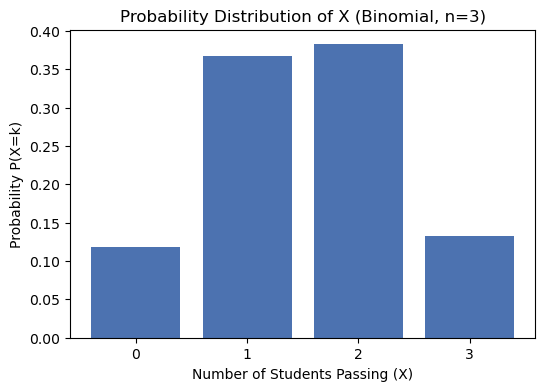

In [14]:
from math import comb
import matplotlib.pyplot as plt

p = empirical_p_pass
n = 3

dist_table = pd.DataFrame({
    'X (num. passing)': [0, 1, 2, 3],
    'P(X=k)': [comb(n, k) * (p**k) * ((1-p)**(n-k)) for k in range(4)]
})
dist_table['P(X=k)'] = dist_table['P(X=k)'].round(4)
print(dist_table)

plt.figure(figsize=(6,4))
plt.bar(dist_table['X (num. passing)'], dist_table['P(X=k)'], color='#4C72B0')
plt.xlabel('Number of Students Passing (X)')
plt.ylabel('Probability P(X=k)')
plt.title('Probability Distribution of X (Binomial, n=3)')
plt.xticks([0,1,2,3])
plt.show()

In [15]:
mean_X = n * p
var_X = n * p * (1 - p)
print(f"Mean E(X) = {mean_X:.3f}")
print(f"Variance Var(X) = {var_X:.3f}")

mean_check = (dist_table['X (num. passing)'] * dist_table['P(X=k)']).sum()
var_check = ((dist_table['X (num. passing)'] - mean_check)**2 * dist_table['P(X=k)']).sum()
print(f"Verification -> Mean: {mean_check:.3f}, Variance: {var_check:.3f}")

Mean E(X) = 1.530
Variance Var(X) = 0.750
Verification -> Mean: 1.530, Variance: 0.750


In [16]:
pip install matplotlib-venn

Note: you may need to restart the kernel to use updated packages.


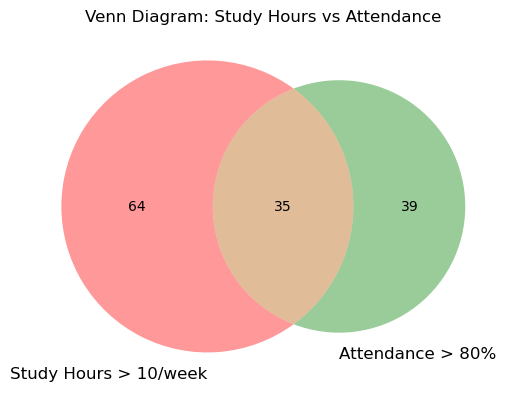

In [17]:
from matplotlib_venn import venn2

set_A = set(df[df['study_hours'] > 10]['student_id'])
set_B = set(df[df['attendance'] > 80]['student_id'])

only_A = len(set_A - set_B)
only_B = len(set_B - set_A)
both = len(set_A & set_B)

plt.figure(figsize=(6,6))
venn2(subsets=(only_A, only_B, both),
      set_labels=('Study Hours > 10/week', 'Attendance > 80%'))
plt.title('Venn Diagram: Study Hours vs Attendance')
plt.show()

In [18]:
contingency = pd.crosstab(df['group_discussion'], df['final_exam_pass'], margins=True, margins_name='Total')
print(contingency)

final_exam_pass   Fail  Pass  Total
group_discussion                   
No                  75    59    134
Yes                 23    43     66
Total               98   102    200


In [19]:
total = len(df)
joint_yes_pass = contingency.loc['Yes', 'Pass'] / total
marginal_pass = contingency.loc['Total', 'Pass'] / total
cond_pass_given_yes = contingency.loc['Yes', 'Pass'] / contingency.loc['Yes', 'Total']

print(f"Joint P(GD=Yes AND Pass) = {joint_yes_pass:.3f}")
print(f"Marginal P(Pass) = {marginal_pass:.3f}")
print(f"Conditional P(Pass | GD=Yes) = {cond_pass_given_yes:.3f}")

Joint P(GD=Yes AND Pass) = 0.215
Marginal P(Pass) = 0.510
Conditional P(Pass | GD=Yes) = 0.652


                                             ***Question 6: Understanding Relationship***
1. Interpretation of Conditional Probability
I calculated two probabilities :-

1.P(Pass) → Overall probability of passing the exam.
2.P(Pass | GD=Yes) → Probability of passing when a student participates in group discussion.
When I compared both values, I observed that , P(Pass | GD=Yes) is different from P(Pass).

This means that participating in group discussion changes the probability of passing. So, I can say that group discussion has an effect on exam performance.

2. Are the Events Independent or Dependent?
Two events are independent if P(A | B) = P(A) , But in my dataset P(Pass | GD=Yes) is not equal to P(Pass).

Therefore, the events are dependent.

Conclusion :-"Participating in group discussion" and "Passing the exam" are dependent events because one affects the other.

                                                ***Question - 7 : Bayes Theorem Applicationn***

In [20]:
p_gd_yes = (df['group_discussion']=='Yes').mean()
expected_if_independent = p_gd_yes * marginal_pass

print(f"P(GD=Yes) * P(Pass) = {expected_if_independent:.3f}")
print(f"Actual Joint P(GD=Yes,Pass) = {joint_yes_pass:.3f}")

if abs(expected_if_independent - joint_yes_pass) < 0.01:
    print("Events appear approximately INDEPENDENT")
else:
    print("Events appear DEPENDENT")

P(GD=Yes) * P(Pass) = 0.168
Actual Joint P(GD=Yes,Pass) = 0.215
Events appear DEPENDENT


In [21]:
P_HA_given_Pass = 0.70
P_HA_given_Fail = 0.40
P_HA = 0.60
P_Pass = 0.50
P_Fail = 1 - P_Pass

P_HA_check = P_HA_given_Pass * P_Pass + P_HA_given_Fail * P_Fail
print(f"Check: P(High Attendance) = {P_HA_check:.3f} (given: {P_HA})")

P_Pass_given_HA = (P_HA_given_Pass * P_Pass) / P_HA
print(f"P(Pass | High Attendance) = {P_Pass_given_HA:.4f} -> {P_Pass_given_HA*100:.2f}%")

Check: P(High Attendance) = 0.550 (given: 0.6)
P(Pass | High Attendance) = 0.5833 -> 58.33%


Final Summary

                                                    **Key findings from this analysis:**
1. **Study hours and attendance** both show a positive relationship with previous test scores and final exam outcome — students who study more and attend more classes tend to score and pass at higher rates.
2. **Group discussion participation** is associated with a higher conditional probability of passing (`P(Pass|GD=Yes)` > `P(Pass)` overall), suggesting these events are **dependent**, not independent.
3. The **Venn diagram** shows a meaningful overlap between high-study-hours and high-attendance students, but many students satisfy only one condition — study habits and attendance are not perfectly aligned.
4. The **Binomial probability distribution** for "number of passes out of 3 students" is centered around the dataset's overall pass rate, with the mean matching `n × p`.
5. **Bayes' Theorem** confirms that observing high attendance meaningfully raises the probability that a student passed (from a 50% prior to ~58.3% posterior), showing attendance is a useful predictive signal — though not deterministic on its own.

**Overall conclusion:** No single factor guarantees success, but *study hours, attendance, previous test performance,* and *group discussion participation* all shift the probability of passing upward when present together. This matches the intuition that consistent engagement (attending, studying, discussing) compounds into better exam outcomes.